In [1]:
# ============================================================
# E02A — TRUE TWO-MODEL (T-LEARNER) UPLIFT SETUP
# ============================================================

In [2]:
!pip install --quiet lightgbm


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from imblearn.ensemble import BalancedRandomForestClassifier

from scipy.stats import randint, uniform

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict
)

import lightgbm as lgb
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV

from datetime import datetime
import joblib
import re

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TARGET_COL = "conversion"
K_VALUES = [100, 200, 300, 400, 500, 750, 1000]
N_SPLITS = 5

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)

In [4]:
cwd = Path.cwd()

if (cwd / "src" / "data" / "dataset" / "hillstrom.csv").exists():
    BASE_DIR = cwd
elif (cwd.parent / "src" / "data" / "dataset" / "hillstrom.csv").exists():
    BASE_DIR = cwd.parent
else:
    BASE_DIR = cwd.parent if cwd.name == "experiments" else cwd

DATA_DIR = BASE_DIR / "src" / "data" / "dataset"
DATA_PATH = DATA_DIR / "hillstrom.csv"

RESULTS_DIR = Path(BASE_DIR) / "src" / "results"
RESULTS_DIR.mkdir(exist_ok=True)

SAVE_MODEL_DIR = Path(BASE_DIR) / "src" / "models"
SAVE_MODEL_DIR.mkdir(exist_ok=True)

# versioning metadata
VERSION = "v1"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# create model directory
model_dir = SAVE_MODEL_DIR / VERSION
model_dir.mkdir(parents=True, exist_ok=True)

print(f"Base directory: {BASE_DIR}")
print(f"Data path: {DATA_PATH}")

Base directory: c:\Users\kuchbhe\Desktop\Projects_doc\lead_scoring
Data path: c:\Users\kuchbhe\Desktop\Projects_doc\lead_scoring\src\data\dataset\hillstrom.csv


In [5]:
SAVE_DIR = BASE_DIR / "docs" / "static_images" / "E02"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

_used_names = {}

def sanitize_filename(text):
    text = re.sub(r"[^\w\s-]", "", text)
    text = re.sub(r"\s+", "_", text.strip())
    return text[:100]

def save_plot(fig, title):

    filename = sanitize_filename(title)

    count = _used_names.get(filename, 0)
    _used_names[filename] = count + 1

    if count > 0:
        filename = f"{filename}_{count}"

    path = SAVE_DIR / f"E02_{filename}.png"

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Saved: {path}")

In [6]:
def load_hillstrom_csv(path):
    if path.exists():
        return pd.read_csv(path)

    try:
        import tensorflow_datasets as tfds
    except ImportError as exc:
        raise FileNotFoundError(
            f"{path} does not exist, and tensorflow_datasets is not installed."
        ) from exc

    DATA_DIR.mkdir(parents=True, exist_ok=True)
    hillstrom_ds = tfds.load("hillstrom", split=["train"], as_supervised=False)
    rows = []

    for sample in tfds.as_numpy(hillstrom_ds[0]):
        rows.append(
            {
                "channel": sample["channel"].decode("utf-8"),
                "conversion": int(sample["conversion"]),
                "history": float(sample["history"]),
                "history_segment": sample["history_segment"].decode("utf-8"),
                "mens": int(sample["mens"]),
                "newbie": int(sample["newbie"]),
                "recency": int(sample["recency"]),
                "segment": sample["segment"].decode("utf-8"),
                "spend": float(sample["spend"]),
                "visit": int(sample["visit"]),
                "womens": int(sample["womens"]),
                "zip_code": sample["zip_code"].decode("utf-8"),
            }
        )

    frame = pd.DataFrame(rows)
    frame.to_csv(path, index=False)
    return frame


hillstrom_df = load_hillstrom_csv(DATA_PATH)

print(hillstrom_df.shape)
display(hillstrom_df.head())

(64000, 12)


,channel,conversion,history,history_segment,mens,newbie,recency,segment,spend,visit,womens,zip_code
0,Multichannel,0,328.160004,3) $200 - $350,0,0,3,Mens E-Mail,0.0,0,1,Urban
1,Web,0,70.860001,1) $0 - $100,1,0,9,No E-Mail,0.0,0,0,Rural
2,Phone,0,94.250000,1) $0 - $100,1,1,12,No E-Mail,0.0,0,0,Surburban
3,Web,0,304.350006,3) $200 - $350,0,0,5,Mens E-Mail,0.0,0,1,Urban
4,Web,0,222.860001,3) $200 - $350,1,0,4,Mens E-Mail,0.0,1,0,Urban


In [15]:
def add_hillstrom_features(frame):

    out = frame.copy()

    # =====================================================
    # SPEND / VALUE FEATURES
    # =====================================================

    # Extract ordinal spend segment
    out["spend_level"] = (
        out["history_segment"]
        .str.extract(r"(\d+)")
        .astype(float)
    )

    # Log spend history
    out["log_history"] = np.log1p(
        out["history"]
    )

    # =====================================================
    # RECENCY INTERACTIONS
    # =====================================================

    # Prefer log-history interaction instead of raw history
    out["log_history_x_recency"] = (
        out["log_history"]
        * out["recency"]
    )
    out["history_x_recency"] = (
        out["history"]
        * out["recency"]
    )

    # New users with spend history
    out["newbie_x_log_history"] = (
        out["newbie"]
        * out["log_history"]
    )

    # =====================================================
    # GENDER AFFINITY FEATURES
    # =====================================================

    out["mens_only"] = (
        (out["mens"] == 1)
        & (out["womens"] == 0)
    ).astype(int)

    out["womens_only"] = (
        (out["mens"] == 0)
        & (out["womens"] == 1)
    ).astype(int)

    out["mens_womens_both"] = (
        (out["mens"] == 1)
        & (out["womens"] == 1)
    ).astype(int)


    # =====================================================
    # CATEGORICAL INTERACTIONS
    # =====================================================

    # Useful interaction:
    # acquisition/source behavior by geography
    out["channel_zip_code"] = (
        out["channel"].astype(str)
        + "_"
        + out["zip_code"].astype(str)
    )
    # acquisition/source behavior by spend level
    out["channel_spend_level"] = (
        out["channel"].astype(str)
        + "_level_"
        + out["spend_level"].astype(str)
    )

    return out


# =========================================================
# FEATURE ENGINEERING
# =========================================================

model_df = add_hillstrom_features(
    hillstrom_df
)

# =========================================================
# REMOVE LEAKAGE / REDUNDANT FEATURES
# =========================================================

non_feature_cols = [

    # Raw versions replaced by transformed features
    "history_segment",

    "history",
    "history_x_recency",

]

model_df = model_df.drop(
    columns=non_feature_cols,
    errors="ignore",
)

# =========================================================
# FEATURE GROUPS
# =========================================================

TREATMENT_COLS = [
        "spend",
        "visit",
        "segment"
    ]

CONTINUOUS_COLS = [
    "log_history",
    "recency",
    "spend_level",
    "log_history_x_recency",
    "newbie_x_log_history",
]

BINARY_COLS = [
    "mens",
    "womens",
    "newbie",
    "mens_only",
    "womens_only",
    "mens_womens_both",
]

CAT_COLS = [
    "channel",
    "zip_code",
    "channel_zip_code",
    "channel_spend_level"
]

FEATURE_COLS = (
    CONTINUOUS_COLS
    + BINARY_COLS
    + CAT_COLS
)

# =========================================================
# FINAL DISPLAY
# =========================================================

print(
    f"Number of engineered features: {len(FEATURE_COLS)}"
)

display(
    model_df[
        FEATURE_COLS + TREATMENT_COLS+ [TARGET_COL]
    ].head()
)

Number of engineered features: 15


,log_history,recency,spend_level,log_history_x_recency,newbie_x_log_history,mens,womens,newbie,mens_only,womens_only,mens_womens_both,channel,zip_code,channel_zip_code,channel_spend_level,spend,visit,segment,conversion
0,5.796544,3,3.0,17.389632,0.000000,0,1,0,0,1,0,Multichannel,Urban,Multichannel_Urban,Multichannel_level_3.0,0.0,0,Mens E-Mail,0
1,4.274720,9,1.0,38.472478,0.000000,1,0,0,1,0,0,Web,Rural,Web_Rural,Web_level_1.0,0.0,0,No E-Mail,0
2,4.556505,12,1.0,54.678060,4.556505,1,0,1,1,0,0,Phone,Surburban,Phone_Surburban,Phone_level_1.0,0.0,0,No E-Mail,0
3,5.721459,5,3.0,28.607293,0.000000,0,1,0,0,1,0,Web,Urban,Web_Urban,Web_level_3.0,0.0,0,Mens E-Mail,0
4,5.411021,4,3.0,21.644083,0.000000,1,0,0,1,0,0,Web,Urban,Web_Urban,Web_level_3.0,0.0,1,Mens E-Mail,0


In [16]:
# ============================================================
# PREP DATA
# ============================================================


model_df["segment"] = model_df["segment"].str.strip()

# Any email vs no email
model_df["treatment"] = (
    model_df["segment"] != "No E-Mail"
).astype(int)


stratify_col = (
    model_df["treatment"].astype(str)
    + "_"
    + model_df["conversion"].astype(str)
)


# ============================================================
# FEATURES
# ============================================================

X = model_df[FEATURE_COLS].copy()

encoders = {}

for col in CAT_COLS:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

y = model_df[TARGET_COL]
t = model_df["treatment"]

# ============================================================
# SPLIT
# ============================================================

X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X,
    y,
    t,
    test_size=0.3,
    random_state=42,
    stratify=stratify_col
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (44800, 15), Test shape: (19200, 15)


In [17]:
# ============================================================
# TREATED / CONTROL SPLITS
# ============================================================

control_mask = (t_train == 0)
treated_mask = (t_train == 1)

X_control = X_train[control_mask]
y_control = y_train[control_mask]

X_treated = X_train[treated_mask]
y_treated = y_train[treated_mask]


print(f"Control group shape: {X_control.shape}, Treated group shape: {X_treated.shape}")

conversion_rate_control = y_control.mean()
conversion_rate_treated = y_treated.mean()

print(f"Control group conversion rate: {conversion_rate_control:.4f}")
print(f"Treated group conversion rate: {conversion_rate_treated:.4f}")

Control group shape: (14914, 15), Treated group shape: (29886, 15)
Control group conversion rate: 0.0057
Treated group conversion rate: 0.0107


In [18]:
# ============================================================
# MODEL 1:
# CONTROL MODEL
#
# mu0(x)
#
# MODEL 2:
# TREATMENT MODEL
#
# mu1(x)
# ============================================================

# params = {
#         "n_estimators": 100,
#         "max_depth": 6,
#         "class_weight": "balanced",
#         "random_state": 42
# }

params = {
    "n_estimators": 50,
    "max_depth": 3,
    "min_child_samples": 100,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE
}

treated_model = lgb.LGBMClassifier(
    **params
)

control_model = lgb.LGBMClassifier(
    **params
)

# treated_model = CalibratedClassifierCV(
#     estimator=treated_base,
#     method="sigmoid",
#     cv=3
# )

# control_model = CalibratedClassifierCV(
#     estimator=control_base,
#     method="sigmoid",
#     cv=3
# )

control_model.fit(
    X_control,
    y_control
)
treated_model.fit(
    X_treated,
    y_treated
)


[LightGBM] [Info] Number of positive: 85, number of negative: 14829
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000197 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 832
[LightGBM] [Info] Number of data points in the train set: 14914, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,3
,learning_rate,0.05
,n_estimators,50
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


In [30]:
# ============================================================
# COMPARE MULTIPLE T-LEARNER BASE MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
from imblearn.ensemble import BalancedRandomForestClassifier

# ============================================================
# MODEL CONFIGS
# ============================================================

models = {

    # --------------------------------------------------------
    # Logistic Regression
    # --------------------------------------------------------

    "logistic_regression": lambda: LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------

    "random_forest": lambda: RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    # --------------------------------------------------------
    # LightGBM
    # --------------------------------------------------------

    "lightgbm": lambda: lgb.LGBMClassifier(
        n_estimators=50,
        max_depth=3,
        min_child_samples=100,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "brf": lambda: BalancedRandomForestClassifier(
            n_estimators=400,
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features="sqrt",
            replacement=True,
            sampling_strategy="all",
            bootstrap=False,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
    )
}

# ============================================================
# STORE RESULTS
# ============================================================

model_results = []

# ============================================================
# TRAIN + EVALUATE
# ============================================================

for model_name, model_fn in models.items():

    print("\n================================================")
    print(f"MODEL: {model_name}")
    print("================================================")

    # --------------------------------------------------------
    # Create treatment/control models
    # --------------------------------------------------------

    treated_model = model_fn()
    control_model = model_fn()

    # --------------------------------------------------------
    # Fit
    # --------------------------------------------------------

    treated_model.fit(
        X_treated,
        y_treated
    )

    control_model.fit(
        X_control,
        y_control
    )

    # --------------------------------------------------------
    # Predict potential outcomes
    # --------------------------------------------------------

    mu1_hat = treated_model.predict_proba(X_test)[:, 1]

    mu0_hat = control_model.predict_proba(X_test)[:, 1]

    # --------------------------------------------------------
    # Estimate uplift
    # --------------------------------------------------------

    tau_hat = mu1_hat - mu0_hat

    # --------------------------------------------------------
    # Create evaluation dataframe
    # --------------------------------------------------------

    temp_results = pd.DataFrame({

        "conversion_score": baseline_prob,

        "uplift_score": tau_hat,

        "treatment_actual": t_test.values,

        "outcome_actual": y_test.values
    })

    # --------------------------------------------------------
    # POLICY EVALUATION
    # --------------------------------------------------------

    K = 500

    topk_conversion = temp_results.nlargest(
        K,
        "conversion_score"
    )

    topk_uplift = temp_results.nlargest(
        K,
        "uplift_score"
    )

    uplift_conversion_policy = empirical_uplift(
        topk_conversion
    )

    uplift_uplift_policy = empirical_uplift(
        topk_uplift
    )

    # --------------------------------------------------------
    # Store metrics
    # --------------------------------------------------------

    model_results.append({

        "model": model_name,

        "tau_mean": tau_hat.mean(),

        "tau_std": tau_hat.std(),

        "conversion_policy_uplift":
            uplift_conversion_policy,

        "uplift_policy_uplift":
            uplift_uplift_policy,

        "uplift_advantage":
            uplift_uplift_policy
            - uplift_conversion_policy
    })

# ============================================================
# FINAL RESULTS
# ============================================================

model_results_df = pd.DataFrame(model_results)

print("\n================================================")
print("MODEL COMPARISON")
print("================================================")

display(
    model_results_df.round(4)
)


MODEL: logistic_regression

MODEL: random_forest

MODEL: lightgbm
[LightGBM] [Info] Number of positive: 319, number of negative: 29567
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001174 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 832
[LightGBM] [Info] Number of data points in the train set: 29886, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,model,tau_mean,tau_std,conversion_policy_uplift,uplift_policy_uplift,uplift_advantage
0,logistic_regression,0.0267,0.0931,0.0167,0.0060,-0.0107
1,random_forest,0.1229,0.1350,0.0167,0.0097,-0.0070
2,lightgbm,0.0657,0.1407,0.0167,0.0125,-0.0042
3,brf,0.0637,0.1449,0.0167,0.0149,-0.0017


Processing logistic_regression
Processing random_forest
Processing lightgbm
[LightGBM] [Info] Number of positive: 319, number of negative: 29567
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001196 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 832
[LightGBM] [Info] Number of data points in the train set: 29886, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

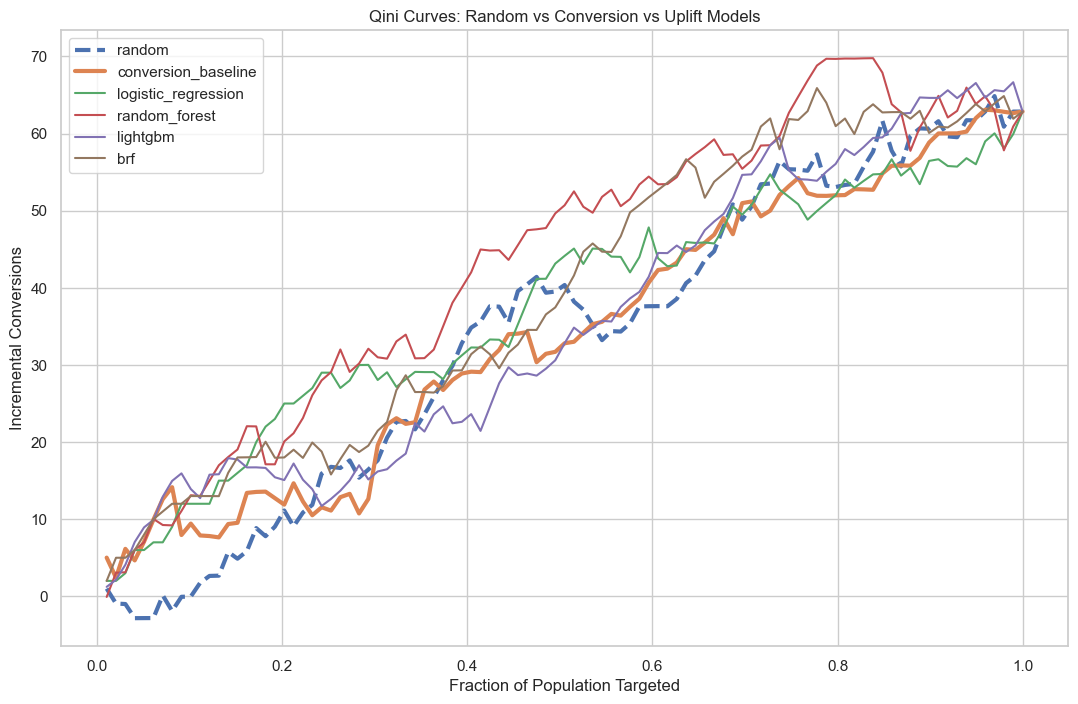

In [31]:
# ============================================================
# QINI CURVES
#
# Compare:
# - Random baseline
# - Conversion ranking
# - All uplift models
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# QINI FUNCTION
# ============================================================

def compute_qini_curve(
    df,
    score_col,
    n_bins=100,
    random_sort=False
):

    # --------------------------------------------------------
    # Random ranking
    # --------------------------------------------------------

    if random_sort:

        df_sorted = df.sample(
            frac=1,
            random_state=42
        ).reset_index(drop=True)

    # --------------------------------------------------------
    # Model ranking
    # --------------------------------------------------------

    else:

        df_sorted = df.sort_values(
            score_col,
            ascending=False
        ).reset_index(drop=True)

    cumulative_gain = []
    population_fraction = []

    total_n = len(df_sorted)

    # --------------------------------------------------------
    # Evaluate cumulative gain
    # --------------------------------------------------------

    for k in np.linspace(
        1,
        total_n,
        n_bins,
        dtype=int
    ):

        subset = df_sorted.iloc[:k]

        treated = subset[
            subset["treatment_actual"] == 1
        ]

        control = subset[
            subset["treatment_actual"] == 0
        ]

        # ----------------------------------------------------
        # Skip invalid subsets
        # ----------------------------------------------------

        if len(treated) == 0 or len(control) == 0:

            cumulative_gain.append(np.nan)

            population_fraction.append(k / total_n)

            continue

        # ----------------------------------------------------
        # Incremental conversions
        # ----------------------------------------------------

        treated_conv = treated["outcome_actual"].sum()

        control_conv = control["outcome_actual"].sum()

        treated_n = len(treated)

        control_n = len(control)

        incremental_gain = (
            treated_conv
            -
            control_conv * (treated_n / control_n)
        )

        cumulative_gain.append(incremental_gain)

        population_fraction.append(k / total_n)

    return (
        np.array(population_fraction),
        np.array(cumulative_gain)
    )

# ============================================================
# BASE EVALUATION DATAFRAME
# ============================================================

base_df = pd.DataFrame({

    "conversion_score": baseline_prob,

    "treatment_actual": t_test.values,

    "outcome_actual": y_test.values
})

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(13, 8))

# ============================================================
# RANDOM BASELINE
# ============================================================

x_rand, y_rand = compute_qini_curve(
    base_df,
    score_col="conversion_score",
    random_sort=True
)

plt.plot(
    x_rand,
    y_rand,
    linestyle="--",
    linewidth=3,
    label="random"
)

# ============================================================
# CONVERSION RANKING BASELINE
# ============================================================

x_conv, y_conv = compute_qini_curve(
    base_df,
    score_col="conversion_score"
)

plt.plot(
    x_conv,
    y_conv,
    linewidth=3,
    label="conversion_baseline"
)

# ============================================================
# UPLIFT MODELS
# ============================================================

for model_name, model_fn in models.items():

    print(f"Processing {model_name}")

    # --------------------------------------------------------
    # Train T-Learner
    # --------------------------------------------------------

    treated_model = model_fn()

    control_model = model_fn()

    treated_model.fit(
        X_treated,
        y_treated
    )

    control_model.fit(
        X_control,
        y_control
    )

    # --------------------------------------------------------
    # Predict uplift
    # --------------------------------------------------------

    mu1_hat = treated_model.predict_proba(X_test)[:, 1]

    mu0_hat = control_model.predict_proba(X_test)[:, 1]

    tau_hat = mu1_hat - mu0_hat

    # --------------------------------------------------------
    # Build dataframe
    # --------------------------------------------------------

    temp_df = pd.DataFrame({

        "uplift_score": tau_hat,

        "treatment_actual": t_test.values,

        "outcome_actual": y_test.values
    })

    # --------------------------------------------------------
    # Compute Qini
    # --------------------------------------------------------

    x_qini, y_qini = compute_qini_curve(
        temp_df,
        score_col="uplift_score"
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.plot(
        x_qini,
        y_qini,
        label=model_name
    )

# ============================================================
# FINAL FORMATTING
# ============================================================

plt.xlabel("Fraction of Population Targeted")

plt.ylabel("Incremental Conversions")

plt.title(
    "Qini Curves: Random vs Conversion vs Uplift Models"
)

plt.legend()

plt.grid(True)

plt.show()

In [19]:
# import joblib


# joblib.dump(
#     treated_model,
#     model_dir / f"treated_model_{VERSION}_{timestamp}.txt"
# )
# joblib.dump(
#     control_model,
#     model_dir / f"control_model_{VERSION}_{timestamp}.txt"
# )

In [20]:
import joblib

coversion_baseline = joblib.load(r"C:\Users\kuchbhe\Desktop\Projects_doc\lead_scoring\src\models\v1\brf_v1_20260521_194145.joblib")
baseline_prob = coversion_baseline.predict_proba(X_test)[:, 1]

In [12]:
# ============================================================
# POTENTIAL OUTCOME ESTIMATES
# ============================================================

mu0_hat = control_model.predict_proba(X_test)[:, 1]

mu1_hat = treated_model.predict_proba(X_test)[:, 1]

# ============================================================
# ESTIMATED UPLIFT
# ============================================================

tau_hat = mu1_hat - mu0_hat

In [21]:
# ============================================================
# BUILD RESULTS DATAFRAME
# ============================================================

results = X_test.copy()

results["treatment_actual"] = t_test.values
results["outcome_actual"] = y_test.values

results["mu0_YprobA0"] = mu0_hat
results["mu1_YprobA1"] = mu1_hat

results["tau_hat"] = tau_hat

# ============================================================
# RANKING COMPARISON
# ============================================================

# Conversion ranking
results["conversion_score"] = baseline_prob

# Uplift ranking
results["uplift_score"] = tau_hat


Saved: c:\Users\kuchbhe\Desktop\Projects_doc\lead_scoring\docs\static_images\E02\E02_Figure_1.png


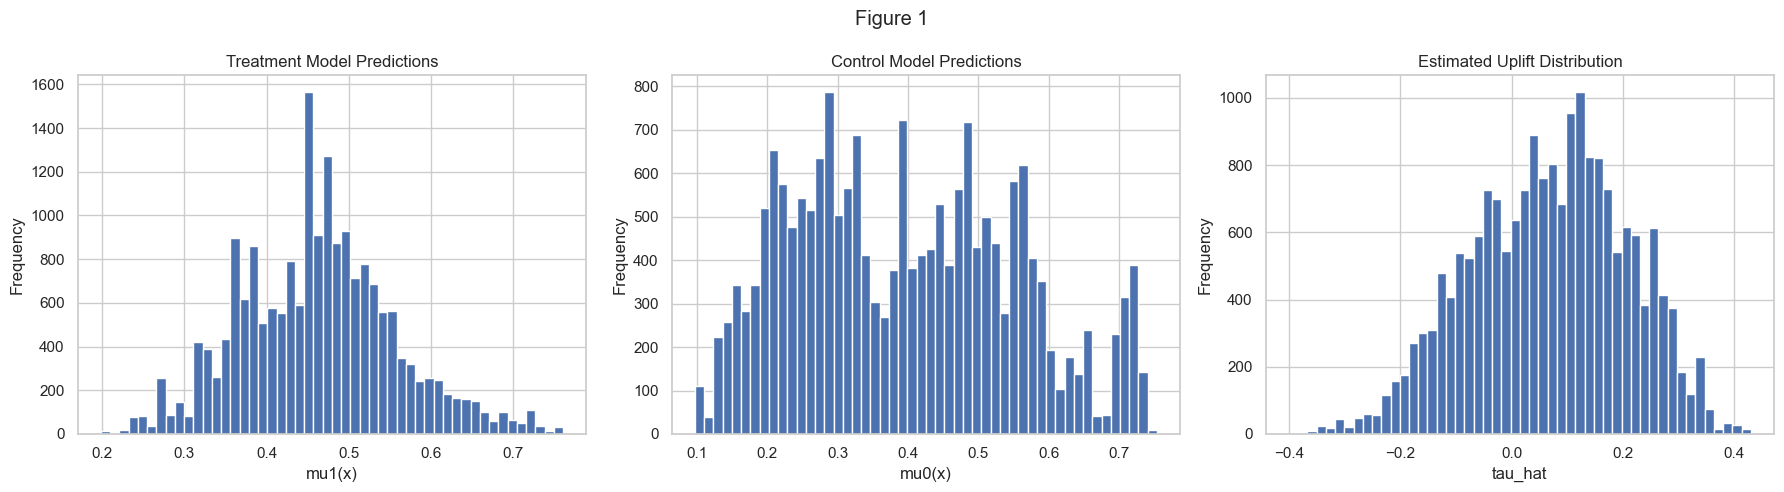

In [22]:
import matplotlib.pyplot as plt

# ============================================================
# PLOT DISTRIBUTIONS
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

# ------------------------------------------------------------
# TREATED MODEL
# ------------------------------------------------------------

axes[0].hist(
    results["mu1_YprobA1"],
    bins=50
)

axes[0].set_title("Treatment Model Predictions")
axes[0].set_xlabel("mu1(x)")
axes[0].set_ylabel("Frequency")

# ------------------------------------------------------------
# CONTROL MODEL
# ------------------------------------------------------------

axes[1].hist(
    results["mu0_YprobA0"],
    bins=50
)

axes[1].set_title("Control Model Predictions")
axes[1].set_xlabel("mu0(x)")
axes[1].set_ylabel("Frequency")

# ------------------------------------------------------------
# UPLIFT DISTRIBUTION
# ------------------------------------------------------------

axes[2].hist(
    results["tau_hat"],
    bins=50
)

axes[2].set_title("Estimated Uplift Distribution")
axes[2].set_xlabel("tau_hat")
axes[2].set_ylabel("Frequency")

fig.suptitle("Figure 1")

plt.tight_layout()
save_plot(fig, fig._suptitle.get_text())
plt.show()

Saved: c:\Users\kuchbhe\Desktop\Projects_doc\lead_scoring\docs\static_images\E02\E02_Treatment_vs_Control_Predictions.png


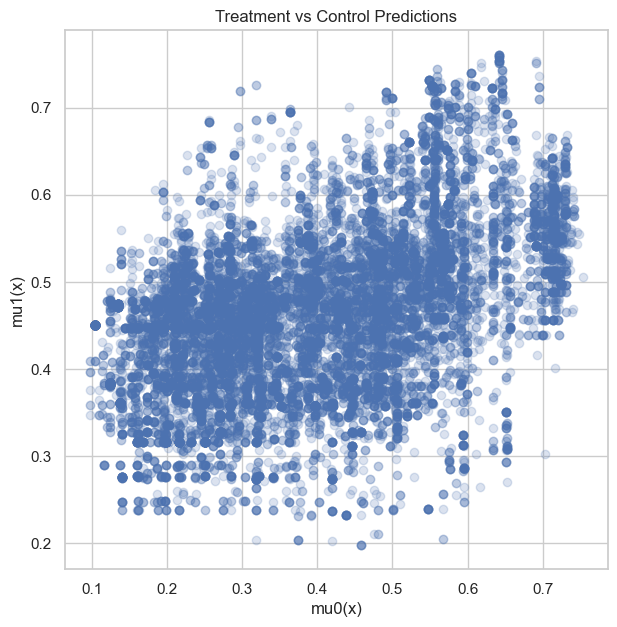

In [23]:
plt.figure(figsize=(7,7))

plt.scatter(
    results["mu0_YprobA0"],
    results["mu1_YprobA1"],
    alpha=0.2
)

plt.xlabel("mu0(x)")
plt.ylabel("mu1(x)")
plt.title("Treatment vs Control Predictions")

fig = plt.gcf()
ax = plt.gca()

save_plot(
    fig,
    ax.get_title()
)

plt.show()

In [24]:
# ============================================================
# TOP-K POLICY COMPARISON
# ============================================================

K = 500

topk_conversion = results.nlargest(
    K,
    "conversion_score"
)

# ------------------------------------------------------------
# Uplift Top-K
# ------------------------------------------------------------

topk_uplift = results.nlargest(
    K,
    "uplift_score"
)

# ============================================================
# EMPIRICAL POLICY VALUE
# ============================================================

def empirical_uplift(model_df):

    treated = model_df[model_df["treatment_actual"] == 1]
    control = model_df[model_df["treatment_actual"] == 0]

    if len(treated) == 0 or len(control) == 0:
        return np.nan

    treated_rate = treated["outcome_actual"].mean()
    control_rate = control["outcome_actual"].mean()

    return treated_rate - control_rate

# ============================================================
# RESULTS
# ============================================================

uplift_conversion_policy = empirical_uplift(
    topk_conversion
)

uplift_uplift_policy = empirical_uplift(
    topk_uplift
)
print("\n================================================")
print("TOP-K POLICY COMPARISON")
print("================================================")

print(f"\nK = {K}")

print("\nConversion Ranking Top-K empirical uplift:")
print(round(uplift_conversion_policy, 4))

print("\nUplift Ranking Top-K empirical uplift:")
print(round(uplift_uplift_policy, 4))



TOP-K POLICY COMPARISON

K = 500

Conversion Ranking Top-K empirical uplift:
0.0167

Uplift Ranking Top-K empirical uplift:
0.0153


In [25]:
# ============================================================
# POLICY COMPARISON ACROSS MULTIPLE K VALUES
# ============================================================

K_VALUES = [50, 100, 200, 500, 1000, 2000]

policy_results = []

for K in K_VALUES:

    # --------------------------------------------------------
    # Conversion Top-K
    # --------------------------------------------------------

    topk_conversion = results.nlargest(
        K,
        "conversion_score"
    )

    # --------------------------------------------------------
    # Uplift Top-K
    # --------------------------------------------------------

    topk_uplift = results.nlargest(
        K,
        "uplift_score"
    )

    # --------------------------------------------------------
    # Empirical uplift
    # --------------------------------------------------------

    uplift_conversion_policy = empirical_uplift(
        topk_conversion
    )

    uplift_uplift_policy = empirical_uplift(
        topk_uplift
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    policy_results.append({
        "K": K,

        "conversion_policy_uplift":
            uplift_conversion_policy,

        "uplift_policy_uplift":
            uplift_uplift_policy,

        "uplift_advantage":
            uplift_uplift_policy
            - uplift_conversion_policy
    })

# ============================================================
# RESULTS DATAFRAME
# ============================================================

policy_results_df = pd.DataFrame(policy_results)

print("\n================================================")
print("TOP-K POLICY COMPARISON")
print("================================================")

display(policy_results_df.round(4))


TOP-K POLICY COMPARISON


,K,conversion_policy_uplift,uplift_policy_uplift,uplift_advantage
0,50,-0.0381,-0.0653,-0.0272
1,100,0.0294,-0.0079,-0.0373
2,200,0.0377,0.0133,-0.0244
3,500,0.0167,0.0153,-0.0013
4,1000,0.0108,0.0150,0.0042
5,2000,0.0070,0.0077,0.0007


In [14]:
# So uplift realistically shouldn't be as high as 80+, but if I calibrate the models, the probabs end up converging to the mean and the uplift shrinks. This is a known issue with two-model approaches, where calibration can lead to reduced variance in predictions, which in turn can diminish the estimated uplift.

In [15]:
# ============================================================
# DEBUGGING UPLIFT PIPELINE
# ============================================================

import numpy as np
import pandas as pd

# ============================================================
# 1. BASIC DISTRIBUTIONS
# ============================================================

print("\n================================================")
print("FULL DATASET")
print("================================================")

print("\nRows:")
print(len(results))

print("\nTreatment distribution:")
print(results["treatment_actual"].value_counts(normalize=True))

print("\nOutcome rate overall:")
print(results["outcome_actual"].mean())

# ============================================================
# 2. GLOBAL TREATMENT EFFECT
# ============================================================

treated_all = results[
    results["treatment_actual"] == 1
]

control_all = results[
    results["treatment_actual"] == 0
]

global_uplift = (
    treated_all["outcome_actual"].mean()
    -
    control_all["outcome_actual"].mean()
)

print("\n================================================")
print("GLOBAL DATASET UPLIFT")
print("================================================")

print(f"\nTreated conversion rate:")
print(round(treated_all["outcome_actual"].mean(), 4))

print(f"\nControl conversion rate:")
print(round(control_all["outcome_actual"].mean(), 4))

print(f"\nGlobal uplift:")
print(round(global_uplift, 4))

# ============================================================
# 3. SCORE DISTRIBUTIONS
# ============================================================

print("\n================================================")
print("SCORE DISTRIBUTIONS")
print("================================================")

print("\nConversion score:")
print(results["conversion_score"].describe())

print("\nUplift score:")
print(results["uplift_score"].describe())

print("\nmu1:")
print(results["mu1_YprobA1"].describe())

print("\nmu0:")
print(results["mu0_YprobA0"].describe())

# ============================================================
# 4. CHECK FOR EXTREME UPLIFT VALUES
# ============================================================

print("\n================================================")
print("TOP POSITIVE UPLIFT")
print("================================================")

print(
    results.sort_values(
        "uplift_score",
        ascending=False
    )[
        [
            "uplift_score",
            "mu1_YprobA1",
            "mu0_YprobA0",
            "outcome_actual",
            "treatment_actual"
        ]
    ].head(20)
)

print("\n================================================")
print("TOP NEGATIVE UPLIFT")
print("================================================")

print(
    results.sort_values(
        "uplift_score",
        ascending=True
    )[
        [
            "uplift_score",
            "mu1_YprobA1",
            "mu0_YprobA0",
            "outcome_actual",
            "treatment_actual"
        ]
    ].head(20)
)

# ============================================================
# 5. CORRELATION CHECK
# ============================================================

print("\n================================================")
print("CORRELATIONS")
print("================================================")

corr = results[
    [
        "conversion_score",
        "uplift_score",
        "mu1_YprobA1",
        "mu0_YprobA0"
    ]
].corr()

print(corr)

# ============================================================
# 6. TOP-K COMPOSITION
# ============================================================

K = 500

topk_conversion = results.nlargest(
    K,
    "conversion_score"
)

topk_uplift = results.nlargest(
    K,
    "uplift_score"
)

print("\n================================================")
print("TOP-K COMPOSITION")
print("================================================")

print("\nConversion Top-K treatment split:")
print(
    topk_conversion["treatment_actual"]
    .value_counts(normalize=True)
)

print("\nUplift Top-K treatment split:")
print(
    topk_uplift["treatment_actual"]
    .value_counts(normalize=True)
)

# ============================================================
# 7. RAW CONVERSION RATES
# ============================================================

print("\n================================================")
print("RAW CONVERSION RATES")
print("================================================")

print("\nConversion Top-K outcome rate:")
print(round(
    topk_conversion["outcome_actual"].mean(),
    4
))

print("\nUplift Top-K outcome rate:")
print(round(
    topk_uplift["outcome_actual"].mean(),
    4
))

# ============================================================
# 8. OBSERVED SUBGROUP UPLIFT
# ============================================================

def subgroup_uplift(df):

    treated = df[
        df["treatment_actual"] == 1
    ]

    control = df[
        df["treatment_actual"] == 0
    ]

    treated_rate = treated[
        "outcome_actual"
    ].mean()

    control_rate = control[
        "outcome_actual"
    ].mean()

    return {
        "treated_rate": treated_rate,
        "control_rate": control_rate,
        "uplift": treated_rate - control_rate,
        "treated_n": len(treated),
        "control_n": len(control)
    }

print("\n================================================")
print("SUBGROUP UPLIFT")
print("================================================")

print("\nConversion Top-K:")
print(subgroup_uplift(topk_conversion))

print("\nUplift Top-K:")
print(subgroup_uplift(topk_uplift))

# ============================================================
# 9. UPLIFT DECILE ANALYSIS
# ============================================================

results["uplift_decile"] = pd.qcut(
    results["uplift_score"],
    10,
    labels=False,
    duplicates="drop"
)

summary = []

for decile in sorted(
    results["uplift_decile"].unique()
):

    temp = results[
        results["uplift_decile"] == decile
    ]

    treated = temp[
        temp["treatment_actual"] == 1
    ]

    control = temp[
        temp["treatment_actual"] == 0
    ]

    treated_rate = treated[
        "outcome_actual"
    ].mean()

    control_rate = control[
        "outcome_actual"
    ].mean()

    uplift = treated_rate - control_rate

    summary.append({
        "decile": decile,
        "n": len(temp),
        "treated_n": len(treated),
        "control_n": len(control),
        "avg_tau_hat": temp[
            "uplift_score"
        ].mean(),
        "treated_rate": treated_rate,
        "control_rate": control_rate,
        "observed_uplift": uplift
    })

uplift_debug_df = pd.DataFrame(summary)

print("\n================================================")
print("UPLIFT DECILE ANALYSIS")
print("================================================")

print(uplift_debug_df)

# ============================================================
# 10. POLICY OVERLAP
# ============================================================

overlap = len(
    set(topk_conversion.index)
    &
    set(topk_uplift.index)
)

print("\n================================================")
print("POLICY OVERLAP")
print("================================================")

print(f"\nOverlap count: {overlap}")
print(f"Overlap %: {round(overlap / K, 4)}")


FULL DATASET

Rows:
19200

Treatment distribution:
treatment_actual
1    0.667083
0    0.332917
Name: proportion, dtype: float64

Outcome rate overall:
0.0090625

GLOBAL DATASET UPLIFT

Treated conversion rate:
0.0107

Control conversion rate:
0.0058

Global uplift:
0.0049

SCORE DISTRIBUTIONS

Conversion score:
count    19200.000000
mean         0.287696
std          0.185933
min          0.004016
25%          0.139534
50%          0.254036
75%          0.406910
max          0.909487
Name: conversion_score, dtype: float64

Uplift score:
count    19200.000000
mean         0.172676
std          0.226216
min         -0.829850
25%          0.049013
50%          0.157708
75%          0.307175
max          0.883822
Name: uplift_score, dtype: float64

mu1:
count    19200.000000
mean         0.287696
std          0.185933
min          0.004016
25%          0.139534
50%          0.254036
75%          0.406910
max          0.909487
Name: mu1_YprobA1, dtype: float64

mu0:
count    19200.000000


Saved: c:\Users\kuchbhe\Desktop\Projects_doc\lead_scoring\docs\static_images\E02\E02_Treatment_vs_Control_Feature_Importance.png


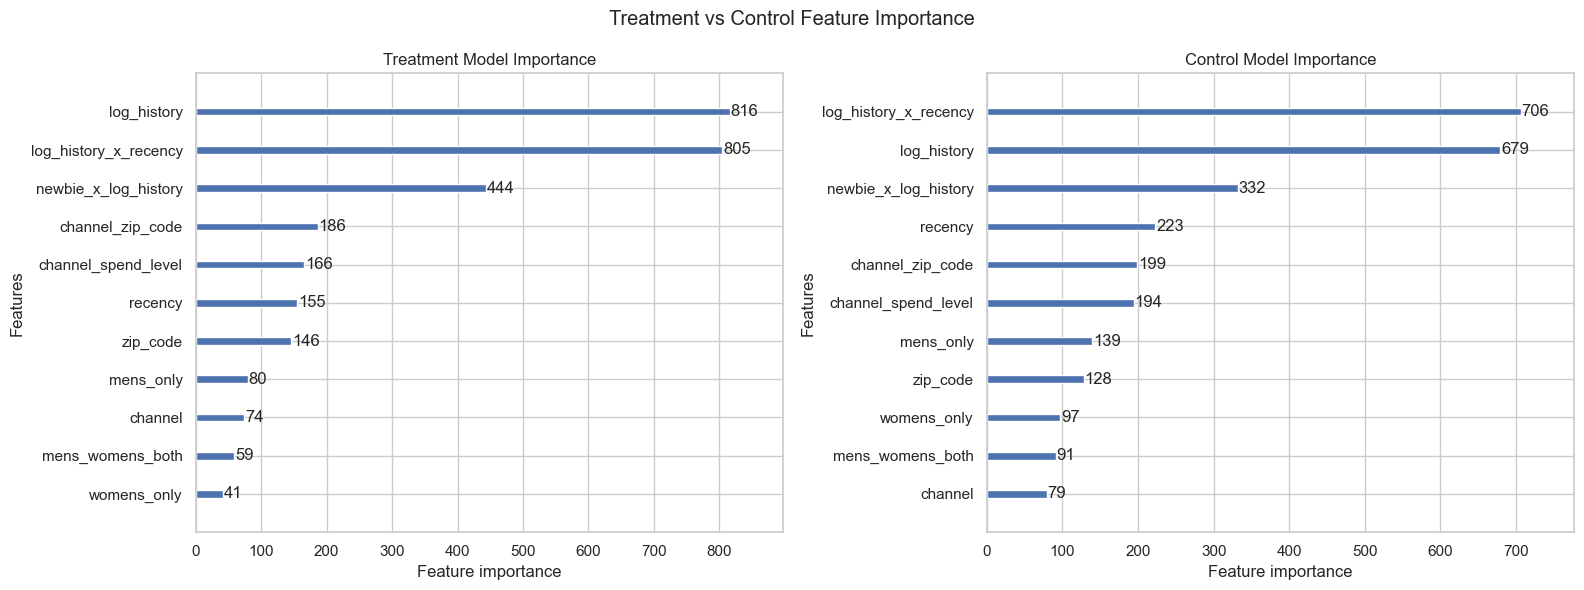

In [22]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

# ============================================================
# TREATMENT MODEL
# ============================================================

lgb.plot_importance(
    treated_model,
    max_num_features=20,
    ax=axes[0]
)

axes[0].set_title(
    "Treatment Model Importance"
)

# ============================================================
# CONTROL MODEL
# ============================================================

lgb.plot_importance(
    control_model,
    max_num_features=20,
    ax=axes[1]
)

axes[1].set_title(
    "Control Model Importance"
)

fig.suptitle(
    "Treatment vs Control Feature Importance"
)

plt.tight_layout()

save_plot(
    fig,
    fig._suptitle.get_text()
)

plt.show()

In [28]:
# ============================================================
# SEGMENT ANALYSIS
# ============================================================

results["score_decile"] = pd.qcut(
    results["conversion_score"],
    10,
    labels=False
)

summary = []

for decile in sorted(results["score_decile"].unique()):

    temp = results[
        results["score_decile"] == decile
    ]

    treated = temp[
        temp["treatment_actual"] == 1
    ]

    control = temp[
        temp["treatment_actual"] == 0
    ]

    treated_rate = treated["outcome_actual"].mean()
    control_rate = control["outcome_actual"].mean()

    uplift = treated_rate - control_rate

    summary.append({
        "decile": decile,
        "treated_rate": treated_rate,
        "control_rate": control_rate,
        "observed_uplift": uplift,
        "avg_conversion_score": temp["conversion_score"].mean()
    })

summary_df = pd.DataFrame(summary)

print("\n================================================")
print("UPLIFT BY CONVERSION SCORE DECILE")
print("================================================")

print(summary_df)

# ============================================================
# SAVE
# ============================================================

# results.to_csv(
#     "hillstrom_tlearner_results.csv",
#     index=False
# )

# summary_df.to_csv(
#     "hillstrom_decile_uplift_summary.csv",
#     index=False
# )

# print("\nSaved:")
# print("- hillstrom_tlearner_results.csv")
# print("- hillstrom_decile_uplift_summary.csv")


UPLIFT BY CONVERSION SCORE DECILE
   decile  treated_rate  control_rate  observed_uplift  avg_conversion_score
0       0      0.010861      0.003160         0.007702              0.042302
1       1      0.007770      0.004732         0.003038              0.094028
2       2      0.011565      0.003130         0.008435              0.140030
3       3      0.011755      0.003200         0.008555              0.184313
4       4      0.013230      0.003150         0.010080              0.230424
5       5      0.006319      0.004580         0.001739              0.279577
6       6      0.007800      0.006270         0.001531              0.335038
7       7      0.008689      0.007657         0.001032              0.406700
8       8      0.014879      0.017107        -0.002229              0.503612
9       9      0.014030      0.004710         0.009320              0.661565


In [18]:
results.sort_values(
    "tau_hat",
    ascending=False
).head()

,log_history,recency,log_history_x_recency,newbie_x_log_history,mens_only,womens_only,mens_womens_both,channel,zip_code,channel_zip_code,channel_spend_level,treatment_actual,outcome_actual,mu0_YprobA0,mu1_YprobA1,tau_hat,conversion_score,uplift_score,uplift_decile,score_decile
20166,5.666496,10,56.664959,0.000000,0,0,1,1,1,4,7,1,0,0.007959,0.891781,0.883822,0.891781,0.883822,9,9
37954,6.937489,2,13.874978,6.937489,0,0,1,2,2,8,18,0,0,0.031562,0.896539,0.864977,0.896539,0.864977,9,9
59382,4.636475,12,55.637700,4.636475,0,1,0,2,1,7,13,1,0,0.002684,0.855018,0.852335,0.855018,0.852335,9,9
21627,3.925729,2,7.851457,3.925729,0,1,0,1,0,3,5,1,0,0.022840,0.874922,0.852081,0.874922,0.852081,9,9
38547,4.620256,12,55.443069,0.000000,0,1,0,2,1,7,13,1,0,0.008992,0.860441,0.851449,0.860441,0.851449,9,9


Saved: c:\Users\kuchbhe\Desktop\Projects_doc\lead_scoring\docs\static_images\E02\E02_Qini_Curve_Uplift_vs_Conversion_Ranking.png


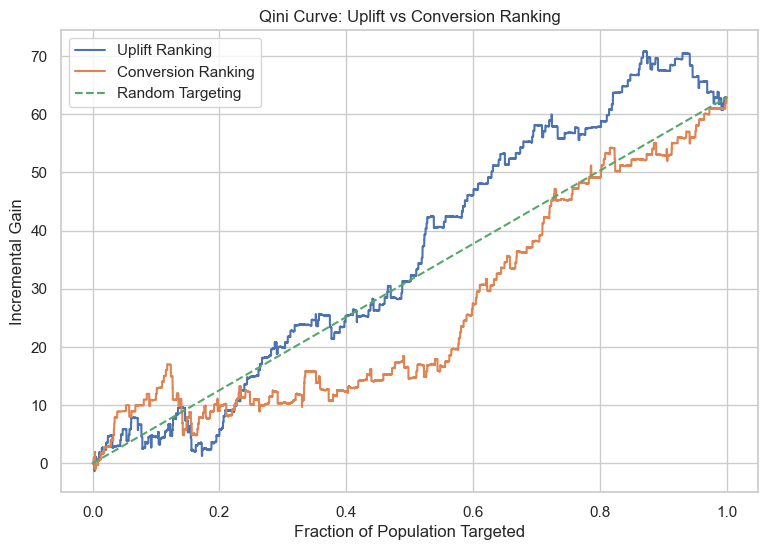

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# QINI CURVE FUNCTION
# ============================================================

def build_qini_curve(
    df,
    score_col,
    treatment_col="treatment_actual",
    outcome_col="outcome_actual"
):

    ranked = df.sort_values(
        score_col,
        ascending=False
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # CUMULATIVE COUNTS
    # --------------------------------------------------------

    ranked["cum_treated"] = (
        ranked[treatment_col]
        .cumsum()
    )

    ranked["cum_control"] = (
        (1 - ranked[treatment_col])
        .cumsum()
    )

    # --------------------------------------------------------
    # CUMULATIVE OUTCOMES
    # --------------------------------------------------------

    ranked["treated_outcome"] = (
        ranked[outcome_col]
        * ranked[treatment_col]
    )

    ranked["control_outcome"] = (
        ranked[outcome_col]
        * (1 - ranked[treatment_col])
    )

    ranked["cum_treated_outcomes"] = (
        ranked["treated_outcome"]
        .cumsum()
    )

    ranked["cum_control_outcomes"] = (
        ranked["control_outcome"]
        .cumsum()
    )

    # --------------------------------------------------------
    # QINI GAIN
    # --------------------------------------------------------

    ranked["qini_gain"] = (
        ranked["cum_treated_outcomes"]
        -
        (
            ranked["cum_control_outcomes"]
            *
            ranked["cum_treated"]
            /
            ranked["cum_control"]
            .replace(0, np.nan)
        )
    )

    ranked["population_fraction"] = (
        np.arange(1, len(ranked)+1)
        / len(ranked)
    )

    return ranked

# ============================================================
# BUILD CURVES
# ============================================================

qini_uplift = build_qini_curve(
    results,
    score_col="uplift_score"
)

qini_conversion = build_qini_curve(
    results,
    score_col="conversion_score"
)

# ============================================================
# RANDOM BASELINE
# ============================================================

random_gain = np.linspace(
    0,
    qini_uplift["qini_gain"].iloc[-1],
    len(qini_uplift)
)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9,6))

# ------------------------------------------------------------
# UPLIFT RANKING
# ------------------------------------------------------------

plt.plot(
    qini_uplift["population_fraction"],
    qini_uplift["qini_gain"],
    label="Uplift Ranking"
)

# ------------------------------------------------------------
# CONVERSION RANKING
# ------------------------------------------------------------

plt.plot(
    qini_conversion["population_fraction"],
    qini_conversion["qini_gain"],
    label="Conversion Ranking"
)

# ------------------------------------------------------------
# RANDOM
# ------------------------------------------------------------

plt.plot(
    qini_uplift["population_fraction"],
    random_gain,
    linestyle="--",
    label="Random Targeting"
)

# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

plt.xlabel(
    "Fraction of Population Targeted"
)

plt.ylabel(
    "Incremental Gain"
)

plt.title(
    "Qini Curve: Uplift vs Conversion Ranking"
)

plt.legend()

fig = plt.gcf()
ax = plt.gca()

save_plot(
    fig,
    ax.get_title()
)

plt.show()

In [26]:
results

,log_history,recency,log_history_x_recency,newbie_x_log_history,mens_only,womens_only,mens_womens_both,channel,zip_code,channel_zip_code,channel_spend_level,treatment_actual,outcome_actual,mu0_YprobA0,mu1_YprobA1,tau_hat,conversion_score,uplift_score
19507,5.428907,11,59.717976,0.000000,1,0,0,1,1,4,7,0,0,0.107459,0.032893,-0.074566,0.032893,-0.074566
56444,4.481985,1,4.481985,0.000000,1,0,0,2,2,8,12,0,0,0.026002,0.371666,0.345665,0.371666,0.345665
34451,6.785757,4,27.143029,6.785757,0,0,1,0,2,2,3,1,0,0.040903,0.140823,0.099920,0.140823,0.099920
56210,4.370586,8,34.964691,4.370586,0,1,0,1,1,4,5,0,0,0.053249,0.092174,0.038924,0.092174,0.038924
5366,3.984344,6,23.906062,3.984344,1,0,0,1,0,3,5,0,0,0.012762,0.062882,0.050120,0.062882,0.050120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19194,3.433665,1,3.433665,3.433665,0,1,0,1,0,3,5,0,0,0.118916,0.568650,0.449734,0.568650,0.449734
32657,3.883829,10,38.838293,3.883829,0,1,0,2,1,7,12,0,0,0.004289,0.367366,0.363077,0.367366,0.363077
46298,4.827113,1,4.827113,0.000000,1,0,0,1,1,4,6,1,0,0.380477,0.383752,0.003275,0.383752,0.003275
55306,5.364807,2,10.729614,5.364807,1,0,0,2,1,7,14,0,0,0.013301,0.260273,0.246972,0.260273,0.246972


In [ ]:
# decile analysis - qini/uplift - auuc - overlap - stability across K

Saved: c:\Users\kuchbhe\Desktop\Projects_doc\lead_scoring\docs\static_images\E02\E02_TOC_Curve_Uplift_vs_Conversion_Ranking.png


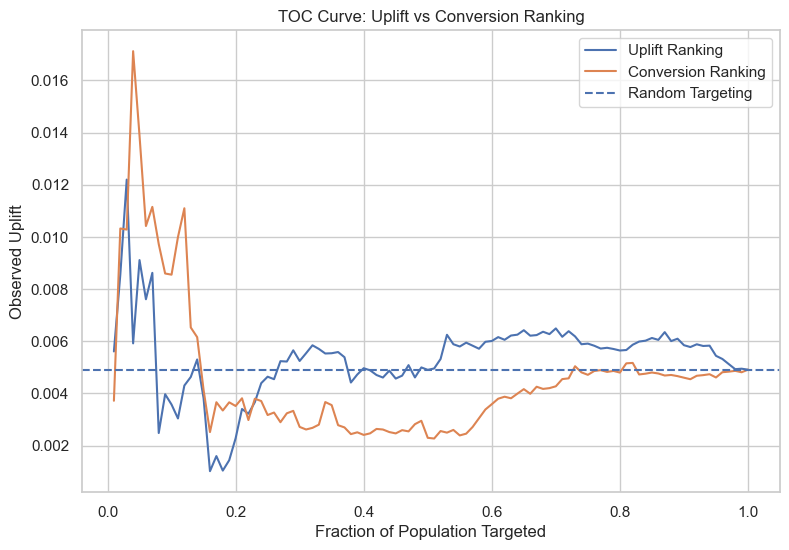

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# TARGETING OPPORTUNITY CURVE (TOC)
# ============================================================

def build_toc_curve(
    df,
    score_col,
    treatment_col="treatment_actual",
    outcome_col="outcome_actual",
    n_bins=100
):

    ranked = df.sort_values(
        score_col,
        ascending=False
    ).reset_index(drop=True)

    fractions = np.linspace(
        0.01,
        1.0,
        n_bins
    )

    uplift_values = []

    n = len(ranked)

    for frac in fractions:

        cutoff = int(n * frac)

        subset = ranked.iloc[:cutoff]

        treated = subset[
            subset[treatment_col] == 1
        ]

        control = subset[
            subset[treatment_col] == 0
        ]

        if len(treated) == 0 or len(control) == 0:
            uplift_values.append(np.nan)
            continue

        treated_rate = treated[
            outcome_col
        ].mean()

        control_rate = control[
            outcome_col
        ].mean()

        uplift = (
            treated_rate
            -
            control_rate
        )

        uplift_values.append(uplift)

    return pd.DataFrame({
        "population_fraction": fractions,
        "uplift": uplift_values
    })

# ============================================================
# BUILD CURVES
# ============================================================

toc_uplift = build_toc_curve(
    results,
    score_col="uplift_score"
)

toc_conversion = build_toc_curve(
    results,
    score_col="conversion_score"
)

# ============================================================
# GLOBAL BASELINE
# ============================================================

global_uplift = (
    results.loc[
        results["treatment_actual"] == 1,
        "outcome_actual"
    ].mean()
    -
    results.loc[
        results["treatment_actual"] == 0,
        "outcome_actual"
    ].mean()
)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9,6))

# ------------------------------------------------------------
# UPLIFT RANKING
# ------------------------------------------------------------

plt.plot(
    toc_uplift["population_fraction"],
    toc_uplift["uplift"],
    label="Uplift Ranking"
)

# ------------------------------------------------------------
# CONVERSION RANKING
# ------------------------------------------------------------

plt.plot(
    toc_conversion["population_fraction"],
    toc_conversion["uplift"],
    label="Conversion Ranking"
)

# ------------------------------------------------------------
# GLOBAL RANDOM BASELINE
# ------------------------------------------------------------

plt.axhline(
    global_uplift,
    linestyle="--",
    label="Random Targeting"
)

# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

plt.xlabel(
    "Fraction of Population Targeted"
)

plt.ylabel(
    "Observed Uplift"
)

plt.title(
    "TOC Curve: Uplift vs Conversion Ranking"
)

plt.legend()

fig = plt.gcf()
ax = plt.gca()

save_plot(
    fig,
    ax.get_title()
)

plt.show()